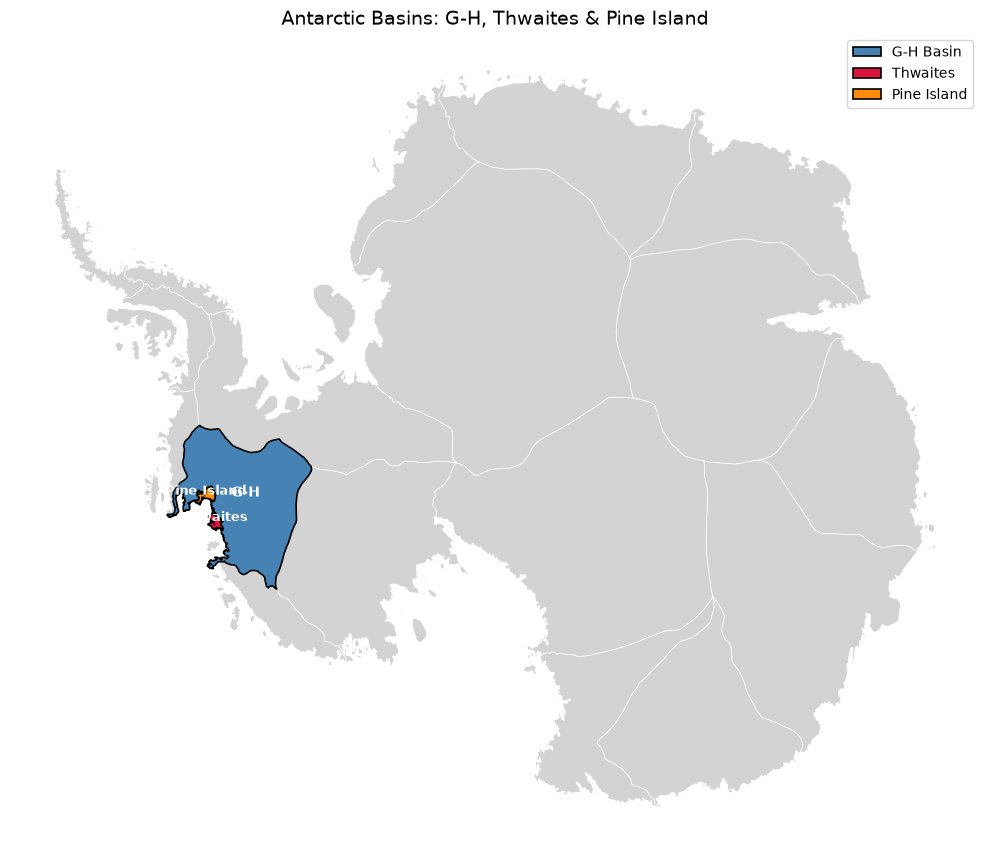

In [19]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

common_data_dir = os.environ.get("COMMON_DATA", "")
base_dir = os.path.join(common_data_dir, "drainage-basins", "MEaSUREs-Antarctic-boundaries-v02")

# Load full shapefiles
basins     = gpd.read_file(os.path.join(base_dir, "Basins_IMBIE_Antarctica_v02.shp"))
iceshelves = gpd.read_file(os.path.join(base_dir, "IceShelf_Antarctica_v02.shp"))

# --- Filter targets ---
gh_basin      = basins[basins["NAME"] == "G-H"]
thwaites      = iceshelves[iceshelves["NAME"].str.contains("Thwaites", case=False)]
pine_island   = iceshelves[iceshelves["NAME"].str.contains("Pine", case=False)]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# Background: all basins in light gray
basins.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)

# Highlighted features
gh_basin.plot(ax=ax,    color="steelblue",   edgecolor="black", linewidth=1.2, label="G-H Basin")
thwaites.plot(ax=ax,    color="crimson",     edgecolor="black", linewidth=1.2, label="Thwaites")
pine_island.plot(ax=ax, color="darkorange",  edgecolor="black", linewidth=1.2, label="Pine Island")

# Labels at centroid
for _, row in gh_basin.iterrows():
    ax.annotate("G-H", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=10, color="white", fontweight="bold")

for _, row in thwaites.iterrows():
    ax.annotate("Thwaites", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

for _, row in pine_island.iterrows():
    ax.annotate("Pine Island", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Antarctic Basins: G-H, Thwaites & Pine Island", fontsize=14)
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figs/antarctic_basins.png")
plt.show()


Boundary shape: (1739, 2)
First few coords (x, y) in meters:
[[-1599824.40361038  -445946.8177648 ]
 [-1598446.89920769  -446930.74948101]
 [-1598053.32652121  -448209.86071208]
 [-1597462.96749149  -449193.79242828]
 [-1596774.21529015  -449488.97194314]]


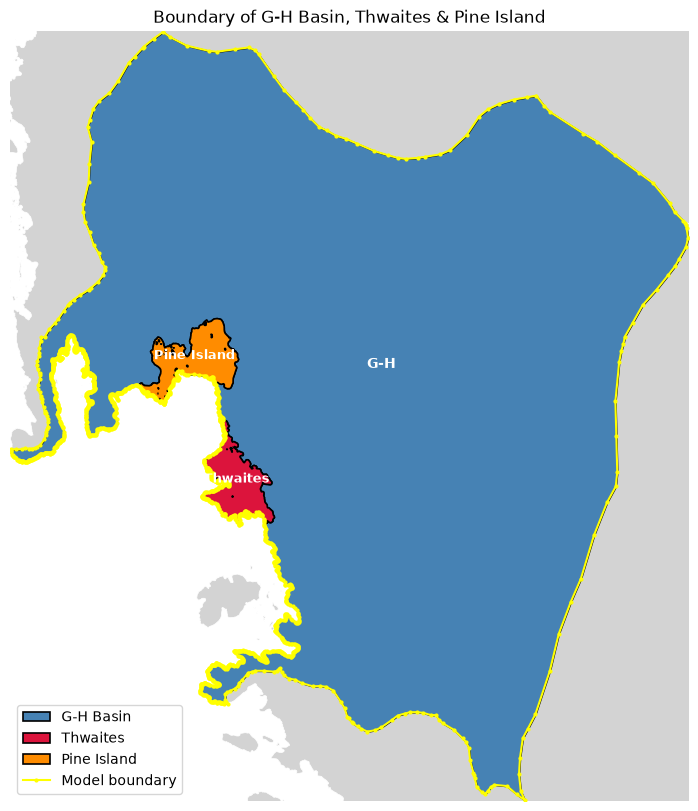

In [33]:
import os
import numpy as np
import geopandas as gpd
from shapely.ops import unary_union

common_data_dir = os.environ.get("COMMON_DATA", "")
base_dir = os.path.join(common_data_dir, "drainage-basins", "MEaSUREs-Antarctic-boundaries-v02")
    
# --- Load shapefiles ---
basins     = gpd.read_file(os.path.join(base_dir, "Basins_IMBIE_Antarctica_v02.shp"))
iceshelves = gpd.read_file(os.path.join(base_dir, "IceShelf_Antarctica_v02.shp"))

# --- Reproject everything to EPSG:3031 (Antarctic Polar Stereographic) ---
basins     = basins.to_crs(epsg=3031)
iceshelves = iceshelves.to_crs(epsg=3031)

# --- Filter the three regions ---
gh_basin    = basins[basins["NAME"] == "G-H"]
thwaites    = iceshelves[iceshelves["NAME"].str.contains("Thwaites", case=False)]
pine_island = iceshelves[iceshelves["NAME"].str.contains("Pine", case=False)]

# --- Merge into one unified polygon ---
combined_geom = unary_union([
    gh_basin.geometry.values[0],
    thwaites.geometry.values[0],
    pine_island.geometry.values[0],
])

# --- Extract exterior boundary coordinates ---
# combined_geom may be a Polygon or MultiPolygon
if combined_geom.geom_type == "Polygon":
    coords = np.array(combined_geom.exterior.coords)  # Nx2

elif combined_geom.geom_type == "MultiPolygon":
    # Take the largest polygon (main landmass, ignore small islands)
    largest = max(combined_geom.geoms, key=lambda g: g.area)
    coords  = np.array(largest.exterior.coords)        # Nx2

print(f"Boundary shape: {coords.shape}")   # e.g. (1842, 2)
print(f"First few coords (x, y) in meters:\n{coords[:5]}")

# --- Optional: save to file ---
np.save("gh_thwaites_pi_boundary_3031.npy", coords)
np.savetxt("gh_thwaites_pi_boundary_3031.csv", coords,
           delimiter=",", header="x_m,y_m", comments="")

# plot the coordinates 

fig, ax = plt.subplots(figsize=(10, 10))

# Background: all basins in light gray
basins.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)

# Highlighted features
gh_basin.plot(ax=ax,    color="steelblue",   edgecolor="black", linewidth=1.2, label="G-H Basin")
thwaites.plot(ax=ax,    color="crimson",     edgecolor="black", linewidth=1.2, label="Thwaites")
pine_island.plot(ax=ax, color="darkorange",  edgecolor="black", linewidth=1.2, label="Pine Island")

# Labels at centroid
for _, row in gh_basin.iterrows():
    ax.annotate("G-H", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=10, color="white", fontweight="bold")

for _, row in thwaites.iterrows():
    ax.annotate("Thwaites", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

for _, row in pine_island.iterrows():
    ax.annotate("Pine Island", xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                ha="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Antarctic Basins: G-H, Thwaites & Pine Island", fontsize=14)
ax.set_axis_off()

ax.set_xlim(coords[:, 0].min() - 1000, coords[:, 0].max() + 1000)
ax.set_ylim(coords[:, 1].min() - 1000, coords[:, 1].max() + 1000)

ax.plot(coords[:, 0], coords[:, 1], '-o', markersize=2, color="yellow", label="Model boundary")
# set y and x limit to the range of the boundary coordinates
ax.legend()
ax.set_xlabel("X (meters)")
ax.set_ylabel("Y (meters)")
ax.set_title("Boundary of G-H Basin, Thwaites & Pine Island")
ax.set_aspect("equal")
ax.grid(True)
plt.savefig("figs/issm_model_boundary.png", dpi=300)
plt.show()